In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/luisfelipevendramim/m5-forecasting-dataset/calendar.csv
/kaggle/input/datasets/luisfelipevendramim/m5-forecasting-dataset/sample_submission.csv
/kaggle/input/datasets/luisfelipevendramim/m5-forecasting-dataset/sell_prices.csv
/kaggle/input/datasets/luisfelipevendramim/m5-forecasting-dataset/sales_train_validation.csv
/kaggle/input/datasets/luisfelipevendramim/m5-forecasting-dataset/sales_train_evaluation.csv


**1 — Importações**

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

**2 — Carregar arquivos**

In [8]:
calendar = pd.read_csv("/kaggle/input/datasets/luisfelipevendramim/m5-forecasting-dataset/calendar.csv")

sales = pd.read_csv("/kaggle/input/datasets/luisfelipevendramim/m5-forecasting-dataset/sales_train_validation.csv")

prices = pd.read_csv("/kaggle/input/datasets/luisfelipevendramim/m5-forecasting-dataset/sell_prices.csv")

**3 — Verificar dimensões**

In [9]:
print(calendar.shape)
print(sales.shape)
print(prices.shape)

(1969, 14)
(30490, 1919)
(6841121, 4)


**4 — Visão geral**

In [10]:
sales.head()

id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_001_CA_1_validation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
1  HOBBIES_1_002_CA_1_validation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1   
2  HOBBIES_1_003_CA_1_validation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1   
3  HOBBIES_1_004_CA_1_validation  HOBBIES_1_004  HOBBIES_1  HOBBIES     CA_1   
4  HOBBIES_1_005_CA_1_validation  HOBBIES_1_005  HOBBIES_1  HOBBIES     CA_1   

  state_id  d_1  d_2  d_3  d_4  d_5  d_6  d_7  d_8  d_9  d_10  d_11  d_12  \
0       CA    0    0    0    0    0    0    0    0    0     0     0     0   
1       CA    0    0    0    0    0    0    0    0    0     0     0     0   
2       CA    0    0    0    0    0    0    0    0    0     0     0     0   
3       CA    0    0    0    0    0    0    0    0    0     0     0     0   
4       CA    0    0    0    0    0    0    0    0    0     0     0     0   

   d_13  d_14  d_15  d_16  d_17  d_18  d_19  d_20  d_21  d_22  d_23  d_24  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     0     0     0     0     0     0     0     0     0     0     0   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_25  d_26  d_27  d_28  d_29  d_30  d_31  d_32  d_33  d_34  d_35  d_36  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     0     0     0     0     0     0     0     0     0     0     0   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_37  d_38  d_39  d_40  d_41  d_42  d_43  d_44  d_45  d_46  d_47  d_48  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     2     0     0     0     2     0     1     0     0     0     0     0   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_49  d_50  d_51  d_52  d_53  d_54  d_55  d_56  d_57  d_58  d_59  d_60  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     2     0     1     0     0     1     1     1     0     2     3   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_61  d_62  d_63  d_64  d_65  d_66  d_67  d_68  d_69  d_70  d_71  d_72  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     1     0     0     0     0     0     1     0     0     1     1     0   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_73  d_74  d_75  d_76  d_77  d_78  d_79  d_80  d_81  d_82  d_83  d_84  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   
3     0     1     0     0     1     2     3     0     2     0     0     2   
4     0     0     0     0     0     0     0     0     0     0     0     0   

   d_85  d_86  d_87  d_88  d_89  d_90  d_91  d_92  d_93  d_94  d_95  d_96  \
0     0     0     0     0     0     0     0     0     0     0     0     0   
1     0     0     0     0     0     0     0     0     0     0     0     0   
2     0     0     0     0     0     0     0     0     0     0     0     0   


**5 — Transformação Long Format**

In [22]:
day_cols = [col for col in sales.columns if col.startswith("d_")]

sales_agg = (
    sales
    .groupby(
        ["store_id", "cat_id"]
    )[day_cols]
    .sum()
    .reset_index()
)

print(sales_agg.shape)

(30, 1915)


In [23]:
sales_long = sales_agg.melt(
    id_vars=[
        "store_id",
        "cat_id"
    ],
    value_vars=day_cols,
    var_name="d",
    value_name="sales"
)

sales_long.shape

(57390, 4)

**6 — Merge com calendário**

In [33]:
calendar_small = calendar[
    [
        "d",
        "date",
        "wm_yr_wk",
        "weekday",
        "month",
        "year",
        "event_name_1",
        "event_type_1",
        "snap_CA",
        "snap_TX",
        "snap_WI"
    ]
]

sales_long = sales_long.merge(
    calendar_small,
    on="d",
    how="left"
)

**7 — Converter datas**

In [34]:
sales_long["date"] = pd.to_datetime(
    sales_long["date"]
)

**8 — Demanda Total Diária**

In [35]:
daily_sales = (
    sales_long
    .groupby("date")["sales"]
    .sum()
)

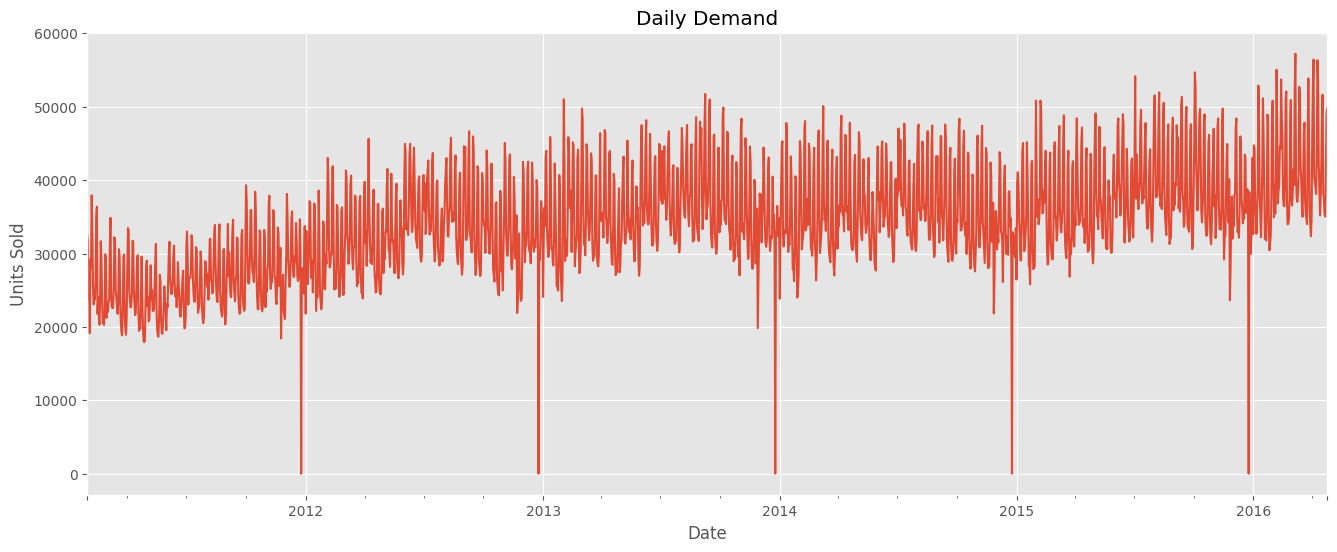

In [36]:
plt.figure(figsize=(16,6))

daily_sales.plot()

plt.title("Daily Demand")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.show()

**Insights:**

* tendência crescente
* sazonalidade anual
* picos em eventos especiais

**9 — Vendas por Categoria**

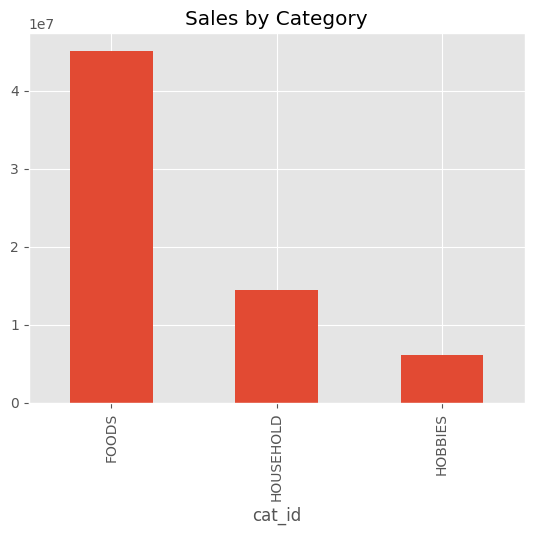

In [37]:
category_sales = (
    sales_long
    .groupby("cat_id")["sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales.plot(
    kind="bar"
)

plt.title("Sales by Category")

plt.show()

**10 — Vendas por Loja**

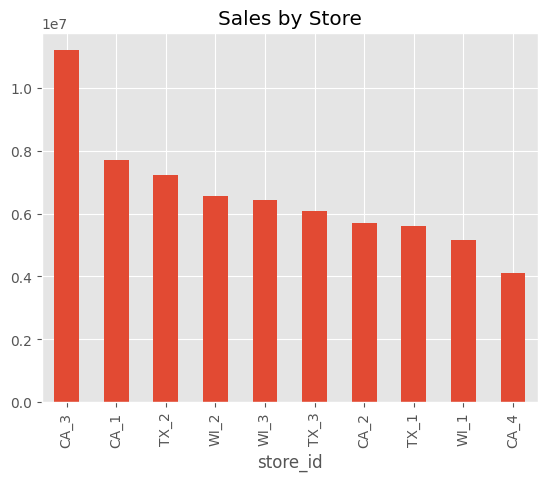

In [38]:
store_sales = (
    sales_long
    .groupby("store_id")["sales"]
    .sum()
    .sort_values(ascending=False)
)

store_sales.plot(
    kind="bar"
)

plt.title("Sales by Store")

plt.show()

**11 — Heatmap Loja x Categoria**

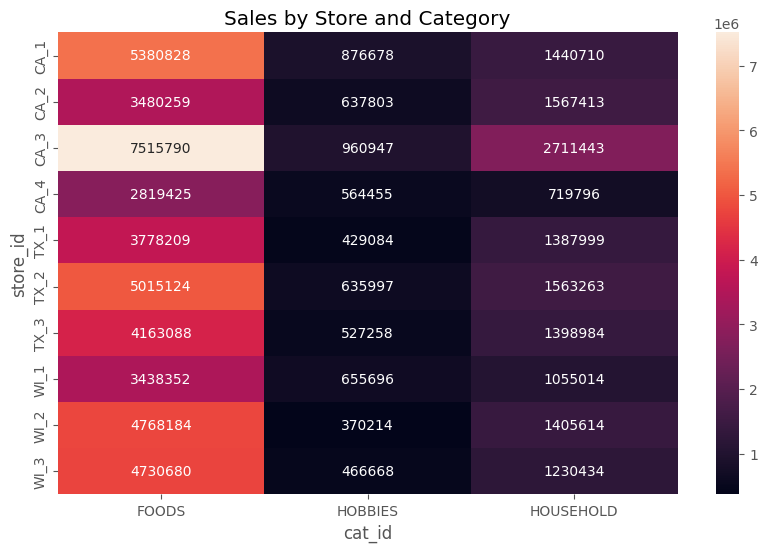

In [39]:
heatmap_data = (
    sales_long
    .groupby(
        ["store_id", "cat_id"]
    )["sales"]
    .sum()
    .unstack()
)

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f"
)

plt.title(
    "Sales by Store and Category"
)

plt.show()

**12 — Vendas por Evento**

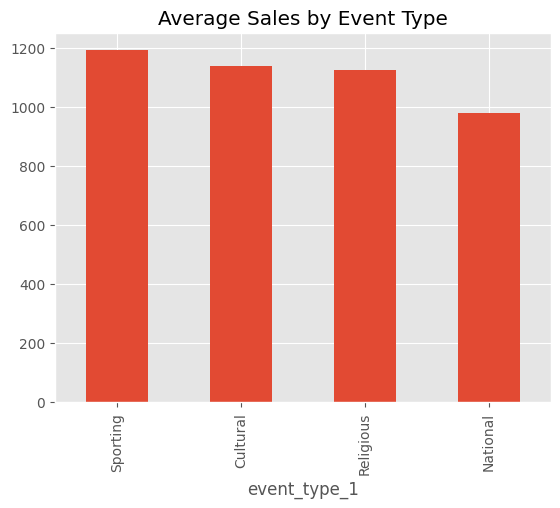

In [40]:
event_sales = (
    sales_long
    .groupby("event_type_1")["sales"]
    .mean()
    .sort_values(ascending=False)
)

event_sales.plot(
    kind="bar"
)

plt.title(
    "Average Sales by Event Type"
)

plt.show()

**13 - Série Temporal por Categoria**

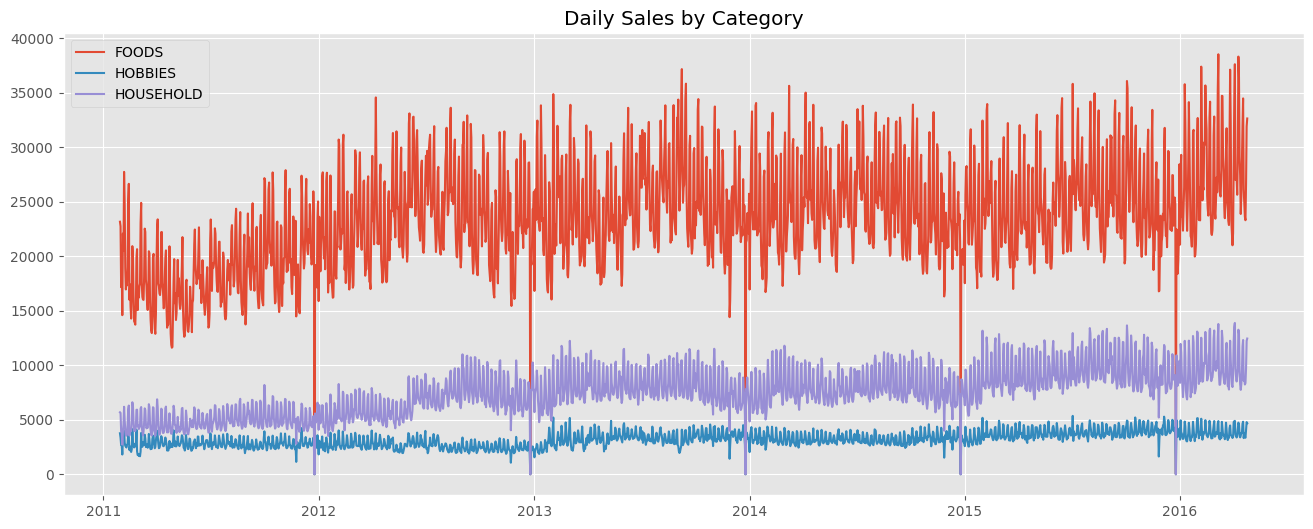

In [41]:
category_ts = (
    sales_long
    .groupby(
        ["date", "cat_id"]
    )["sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(16,6))

for category in category_ts["cat_id"].unique():

    subset = category_ts[
        category_ts["cat_id"] == category
    ]

    plt.plot(
        subset["date"],
        subset["sales"],
        label=category
    )

plt.legend()

plt.title(
    "Daily Sales by Category"
)

plt.show()

**14 - Dataset final para modelagem**

In [42]:
sales_long.to_csv(
    "m5_processed.csv",
    index=False
)

O dataset original possuía mais de 58 milhões de observações após o pivot para formato temporal. Para tornar o pipeline mais eficiente e alinhado ao nível decisório do negócio, agreguei inicialmente as vendas por Store e Category, reduzindo o volume para cerca de 57 mil registros sem perder a capacidade de capturar padrões de demanda relevantes para planejamento e reposição.